# Statistical Methods in Imaging (SMI) Conference, 2026.
# Empowering Large Language Models with Statistics: A Practical Tutorial for Medical Imaging
**Ernest (Khashayar) Namdar, Dominik A. Deniffel, Pascal Tyrrell**

This tutorial focuses on classifying Acute Ischemic Stroke (AIS) from Radiology reports. We will use the `Label` and `Text` columns for a binary classification task.

Several similar pipelines were discussed in our publication:
```bibtex
@inproceedings{10.1117/12.3084682,
author = {Khashayar Namdar and Saeidehsadat Mirjalili and Lauren Erdman and Dominik A. Deniffel and Keith Brunt and Leo Anthony Celi},
title = {{Comparative evaluation of machine learning and large language model pipelines for identifying acute ischemic stroke in radiology reports}},
volume = {13926},
booktitle = {Medical Imaging 2026: Computer-Aided Diagnosis},
editor = {Axel Wism{\"u}ller and Thomas Martin Deserno},
organization = {International Society for Optics and Photonics},
publisher = {SPIE},
pages = {139261S},
keywords = {Stroke, NLP, Machine Learning, Large Language Models},
year = {2026},
doi = {10.1117/12.3084682},
URL = {https://doi.org/10.1117/12.3084682}
}
```

Also, the source for the dataset is:
```bibtex
@article{10.1371/journal.pone.0212778,
    doi = {10.1371/journal.pone.0212778},
    author = {Kim, Chulho AND Zhu, Vivienne AND Obeid, Jihad AND Lenert, Leslie},
    journal = {PLOS ONE},
    publisher = {Public Library of Science},
    title = {Natural language processing and machine learning algorithm to identify brain MRI reports with acute ischemic stroke},
    year = {2019},
    month = {02},
    volume = {14},
    url = {https://doi.org/10.1371/journal.pone.0212778},
    pages = {1-13},
    number = {2},
}
```


## Dataset Biases and Shortcuts
Compare predictions and `Original Text Length` column. Plot AUC of different bins.

/tmp/ipykernel_161748/1246121990.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bin_labels_used, y=auc_by_bin, palette="viridis")


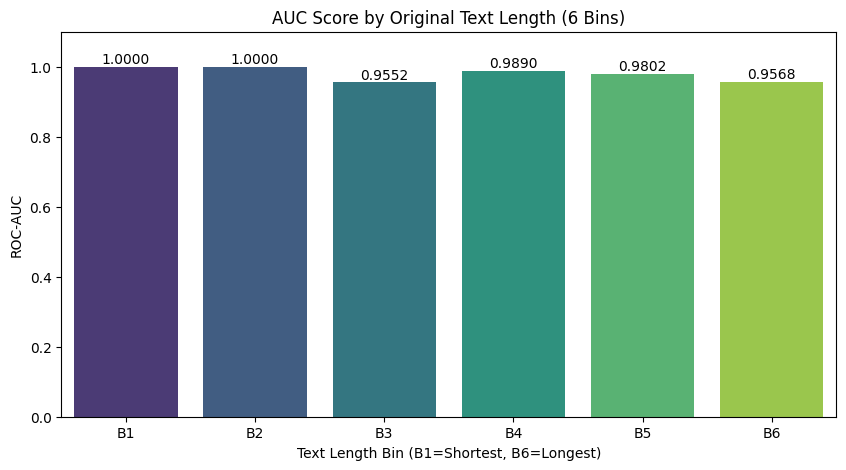

/tmp/ipykernel_161748/1246121990.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bin_labels_used, y=prop_by_bin, palette="magma")


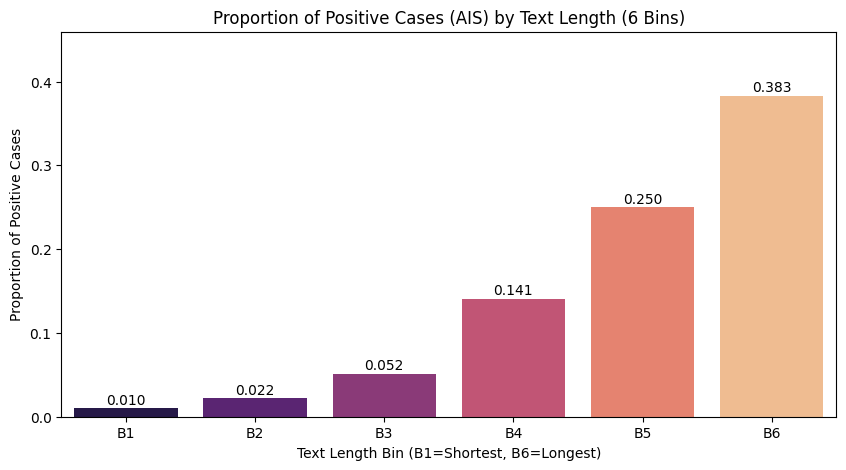

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import chi2

# Load data
df = pd.read_csv('../data/AIS.csv')
preds_df = pd.read_csv('../results/predictions.csv')

# Merge
data = df.merge(preds_df, on=['ID', 'Label'])

# Set the number of bins here
n_bins = 6

# Bin the "Original Text Length"
# We use rank(method='first') to ensure exactly equal-sized bins even if there are duplicate text lengths.
bin_labels = [f'B{i+1}' for i in range(n_bins)]
data['Length_Bin'] = pd.qcut(data['Original Text Length'].rank(method='first'), q=n_bins, labels=bin_labels)

auc_by_bin = []
prop_by_bin = []
bin_labels_used = []

for bin_label, group in data.groupby('Length_Bin', observed=True):
    if len(group['Label'].unique()) > 1:
        auc = roc_auc_score(group['Label'], group['predictions'])
        auc_by_bin.append(auc)
    else:
        auc_by_bin.append(np.nan)
        
    prop = group['Label'].mean()
    prop_by_bin.append(prop)
    bin_labels_used.append(bin_label)

# Plot AUC
plt.figure(figsize=(10, 5))
sns.barplot(x=bin_labels_used, y=auc_by_bin, palette="viridis")
plt.ylim(0, 1.1)
plt.title(f"AUC Score by Original Text Length ({n_bins} Bins)")
plt.ylabel("ROC-AUC")
plt.xlabel(f"Text Length Bin (B1=Shortest, B{n_bins}=Longest)")
for i, v in enumerate(auc_by_bin):
    if not np.isnan(v):
        plt.text(i, v + 0.01, f"{v:.4f}", ha='center')
plt.show()

# Plot Proportion of Positive Cases
plt.figure(figsize=(10, 5))
sns.barplot(x=bin_labels_used, y=prop_by_bin, palette="magma")
plt.ylim(0, max(prop_by_bin) * 1.2 if max(prop_by_bin) > 0 else 1.0)
plt.title(f"Proportion of Positive Cases (AIS) by Text Length ({n_bins} Bins)")
plt.ylabel("Proportion of Positive Cases")
plt.xlabel(f"Text Length Bin (B1=Shortest, B{n_bins}=Longest)")
for i, v in enumerate(prop_by_bin):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')
plt.show()


## Unigram Significance
Check if the presence of any unigram is a significant predictor of the Label. We lowercase the text to reduce unigrams, then use CountVectorizer and chi-squared test.

In [5]:
# Lowercase text
data['Lower_Text'] = data['Text'].str.lower()

# Vectorize unigrams
vectorizer = CountVectorizer(binary=True, min_df=5)
X_text = vectorizer.fit_transform(data['Lower_Text'])
y_true = data['Label'].values

# Calculate Chi2 significance
chi2_stats, p_values = chi2(X_text, y_true)

feature_names = vectorizer.get_feature_names_out()
unigram_df = pd.DataFrame({
    'Unigram': feature_names,
    'Chi2': chi2_stats,
    'p_value': p_values
})

# Display top 5 predictors
unigram_df = unigram_df.sort_values(by='Chi2', ascending=False)
print("Top 10 Unigram Predictors:")
display(unigram_df.head(10))


Top 10 Unigram Predictors:


,Unigram,Chi2,p_value
16,acute,1914.117799,0.000000e+00
550,restrictions,882.919170,5.070226e-194
316,infarct,392.787500,2.046636e-87
151,cortex,383.169591,2.540382e-85
434,multifocal,255.236296,1.874676e-57
444,no,249.302515,3.685518e-56
495,parietal,238.235179,9.539401e-54
146,corona,210.446328,1.097717e-47
535,radiata,205.698006,1.192571e-46
276,gyrus,200.296296,1.799590e-45


## Outlier Analysis
Identify the top False Positive (highest predicted probability for a true negative) and top False Negative (lowest predicted probability for a true positive).

In [7]:
# Top False Positive (Label = 0, High Prediction)
fp_data = data[data['Label'] == 0].sort_values(by='predictions', ascending=False)
top_fp = fp_data.iloc[0]

# Top False Negative (Label = 1, Low Prediction)
fn_data = data[data['Label'] == 1].sort_values(by='predictions', ascending=True)
top_fn = fn_data.iloc[0]

print("="*60)
print(f"TOP FALSE POSITIVE (Predicted: {top_fp['predictions']:.4f}, True Label: 0)")
print("="*60)
print(top_fp['Text'])
print("\n")

print("="*60)
print(f"TOP FALSE NEGATIVE (Predicted: {top_fn['predictions']:.4f}, True Label: 1)")
print("="*60)
print(top_fn['Text'])


TOP FALSE POSITIVE (Predicted: 1.0000, True Label: 0)
1. Cystic encephalomalacia or old infarct in right inferior posterior cerebellar hemisphere.
; Old infarct in right internal carotid artery territory.
2. No diffusion restriction.
3. Multiple old lacunar infarcts in both basal ganglias.
4. Multiple old small infarcts in both cerebral deep and subcortical white matter.
5. magnetic resonance angiography;
 Focal severe stenosis of left proximal middle cerebral artery (proximal M1).
 Diffuse steno-occlusive disease of right distal vertebral artery (V4).
  ; Intravascular signal intensity at the corresponding area on gradient echo image.
   -Intravascular thrombosis of right distal vertebral artery.
 Irregular luminal narrowing or steno-occlusive disease of left posterior cerebral artery (P4).
  
 --
 Multifocal irregular luminal narrowing of right vertebral artery.
  ; Multiple steno-occlusive disease.
 Focal severe stenosis of left vertebral artery ostium.
 Focal stenosis of left dista